In [1]:
# ==========================================================
# Cell 1 : Import Libraries
# ==========================================================

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from torch.utils.data import DataLoader

from pathlib import Path

print("Libraries Imported Successfully!")

Libraries Imported Successfully!


In [2]:
# ==========================================================
# Cell 2 : Project Directories
# ==========================================================

from pathlib import Path

PROJECT_DIR = Path.cwd().parent

DATA_DIR = PROJECT_DIR / "data"

# Correct folder
PROCESSED_DIR = PROJECT_DIR / "processed_data"

MODEL_DIR = PROJECT_DIR / "saved_models"

RESULT_DIR = PROJECT_DIR / "results"
METRICS_DIR = RESULT_DIR / "metrics"
HISTORY_DIR = RESULT_DIR / "history"

FIGURE_DIR = RESULT_DIR / "figures"

MODEL_DIR.mkdir(exist_ok=True)
RESULT_DIR.mkdir(exist_ok=True)
METRICS_DIR.mkdir(parents=True, exist_ok=True)
HISTORY_DIR.mkdir(parents=True, exist_ok=True)
FIGURE_DIR.mkdir(parents=True, exist_ok=True)

print("Project :", PROJECT_DIR)
print("Processed :", PROCESSED_DIR)
print("Models :", MODEL_DIR)
print("Figures :", FIGURE_DIR)

Project : C:\Users\ashut\Documents\Rainfall Prediction
Processed : C:\Users\ashut\Documents\Rainfall Prediction\processed_data
Models : C:\Users\ashut\Documents\Rainfall Prediction\saved_models
Figures : C:\Users\ashut\Documents\Rainfall Prediction\figures


In [3]:
# ==========================================================
# Cell 3 : Device
# ==========================================================

DEVICE = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print("Device :", DEVICE)

Device : cuda


In [4]:
# ==========================================================
# Cell 4 : Load Dataset
# ==========================================================

X_train = np.load(PROCESSED_DIR / "X_train.npy")
y_train = np.load(PROCESSED_DIR / "y_train.npy")

X_val = np.load(PROCESSED_DIR / "X_val.npy")
y_val = np.load(PROCESSED_DIR / "y_val.npy")

X_test = np.load(PROCESSED_DIR / "X_test.npy")
y_test = np.load(PROCESSED_DIR / "y_test.npy")

print("Train :", X_train.shape)
print("Validation :", X_val.shape)
print("Test :", X_test.shape)

Train : (6387, 7, 129, 135)
Validation : (1369, 7, 129, 135)
Test : (1369, 7, 129, 135)


In [5]:
# ==========================================================
# Cell 5 : Convert to Tensor
# ==========================================================

X_train = torch.FloatTensor(X_train)
y_train = torch.FloatTensor(y_train)

X_val = torch.FloatTensor(X_val)
y_val = torch.FloatTensor(y_val)

X_test = torch.FloatTensor(X_test)
y_test = torch.FloatTensor(y_test)

print("Converted to Torch Tensors!")

Converted to Torch Tensors!


In [6]:
import sys
from pathlib import Path

PROJECT_DIR = Path.cwd().parent

if str(PROJECT_DIR) not in sys.path:
    sys.path.append(str(PROJECT_DIR))

print(PROJECT_DIR)

from utils.dataset import RainfallDataset

print("RainfallDataset imported successfully!")

C:\Users\ashut\Documents\Rainfall Prediction
RainfallDataset imported successfully!


In [7]:
# ==========================================================
# Cell 7 : Create Dataset
# ==========================================================

train_dataset = RainfallDataset(
    X_train,
    y_train
)

val_dataset = RainfallDataset(
    X_val,
    y_val
)

test_dataset = RainfallDataset(
    X_test,
    y_test
)

print("Datasets Created Successfully!")

C:\Users\ashut\Documents\Rainfall Prediction\utils\dataset.py:9: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  self.X = torch.tensor(X, dtype=torch.float32)
C:\Users\ashut\Documents\Rainfall Prediction\utils\dataset.py:10: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  self.y = torch.tensor(y, dtype=torch.float32)


Datasets Created Successfully!


In [8]:
from pathlib import Path

print((Path.cwd().parent / "utils").exists())
print(list((Path.cwd().parent / "utils").iterdir()))

True
[WindowsPath('C:/Users/ashut/Documents/Rainfall Prediction/utils/dataset.py'), WindowsPath('C:/Users/ashut/Documents/Rainfall Prediction/utils/early_stopping.py'), WindowsPath('C:/Users/ashut/Documents/Rainfall Prediction/utils/metrics.py'), WindowsPath('C:/Users/ashut/Documents/Rainfall Prediction/utils/trainer.py'), WindowsPath('C:/Users/ashut/Documents/Rainfall Prediction/utils/__pycache__')]


In [9]:
# ==========================================================
# Cell 8 : DataLoader
# ==========================================================

BATCH_SIZE = 8

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False
)

print("DataLoaders Ready!")

DataLoaders Ready!


In [10]:
# ==========================================================
# Cell 9 : Import Model
# ==========================================================

from models.cnn_bilstm_attention import CNNBiLSTMAttention

print("CNN + BiLSTM + Attention Imported Successfully!")

CNN + BiLSTM + Attention Imported Successfully!


In [11]:
# ==========================================================
# Cell 10 : Build Model
# ==========================================================

cnn_attention = CNNBiLSTMAttention().to(DEVICE)

print(cnn_attention)

CNNBiLSTMAttention(
  (cnn): Sequential(
    (0): Conv2d(1, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): ReLU()
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (6): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (7): ReLU()
    (8): AdaptiveAvgPool2d(output_size=(1, 1))
  )
  (lstm): LSTM(64, 128, num_layers=2, batch_first=True, dropout=0.3, bidirectional=True)
  (attention): Attention(
    (attention): Linear(in_features=256, out_features=1, bias=True)
  )
  (fc): Sequential(
    (0): Linear(in_features=256, out_features=512, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.3, inplace=False)
    (3): Linear(in_features=512, out_features=17415, bias=True)
  )
)


In [12]:
# ==========================================================
# Cell 11 : Training Configuration
# ==========================================================

LEARNING_RATE = 0.001
EPOCHS = 30

criterion = nn.MSELoss()

optimizer = torch.optim.Adam(
    cnn_attention.parameters(),
    lr=LEARNING_RATE
)

print("Learning Rate :", LEARNING_RATE)
print("Epochs :", EPOCHS)
print("Optimizer Ready!")

Learning Rate : 0.001
Epochs : 30
Optimizer Ready!


In [13]:
# ==========================================================
# Import Project Utilities
# ==========================================================

from utils.early_stopping import EarlyStopping
from utils.trainer import train_one_epoch, validate
from utils.metrics import evaluate_model, print_metrics

print("Project Utilities Imported Successfully!")

Project Utilities Imported Successfully!


In [14]:
# ==========================================================
# Cell 12 : Early Stopping
# ==========================================================

early_stopping = EarlyStopping(
    patience=5,
    delta=0
)

history = {
    "train_loss": [],
    "val_loss": []
}

best_loss = float("inf")

print("EarlyStopping Ready!")

EarlyStopping Ready!


In [15]:
# ==========================================================
# Cell 13 : Training
# ==========================================================

for epoch in range(EPOCHS):

    train_loss = train_one_epoch(
        cnn_attention,
        train_loader,
        optimizer,
        criterion,
        DEVICE
    )

    val_loss = validate(
        cnn_attention,
        val_loader,
        criterion,
        DEVICE
    )

    history["train_loss"].append(train_loss)
    history["val_loss"].append(val_loss)

    print(
        f"Epoch {epoch+1:02d}/{EPOCHS} | "
        f"Train Loss: {train_loss:.6f} | "
        f"Val Loss: {val_loss:.6f}"
    )

    if val_loss <= early_stopping.best_loss:

        torch.save(
            cnn_attention.state_dict(),
            MODEL_DIR / "cnn_bilstm_attention.pth"
        )

    early_stopping(val_loss)

    if early_stopping.early_stop:

        print(f"\nEarly stopping at Epoch {epoch+1}")
        break

Epoch 01/30 | Train Loss: 0.000039 | Val Loss: 0.000036
Epoch 02/30 | Train Loss: 0.000034 | Val Loss: 0.000036
Epoch 03/30 | Train Loss: 0.000034 | Val Loss: 0.000036
Epoch 04/30 | Train Loss: 0.000034 | Val Loss: 0.000036
Epoch 05/30 | Train Loss: 0.000034 | Val Loss: 0.000036
Epoch 06/30 | Train Loss: 0.000034 | Val Loss: 0.000036
Epoch 07/30 | Train Loss: 0.000034 | Val Loss: 0.000036
Epoch 08/30 | Train Loss: 0.000034 | Val Loss: 0.000036
Epoch 09/30 | Train Loss: 0.000034 | Val Loss: 0.000036
Epoch 10/30 | Train Loss: 0.000034 | Val Loss: 0.000036
Epoch 11/30 | Train Loss: 0.000034 | Val Loss: 0.000036

Early stopping at Epoch 11


In [16]:
# ==========================================================
# Cell 14 : Load Best Model
# ==========================================================

cnn_attention.load_state_dict(
    torch.load(
        MODEL_DIR / "cnn_bilstm_attention.pth",
        map_location=DEVICE
    )
)

cnn_attention.eval()

print("Best CNN + BiLSTM + Attention Model Loaded!")

Best CNN + BiLSTM + Attention Model Loaded!


In [17]:
predictions = []
targets = []

with torch.no_grad():

    for X, y in test_loader:

        X = X.to(DEVICE)

        pred = cnn_attention(X)

        predictions.append(pred.cpu().numpy())

        targets.append(y.numpy())

print("Prediction Completed!")

Prediction Completed!


In [18]:
# ==========================================================
# Cell 16 : Convert Predictions
# ==========================================================

y_pred = np.concatenate(predictions, axis=0)
y_true = np.concatenate(targets, axis=0)

print("Prediction Shape :", y_pred.shape)
print("Ground Truth Shape :", y_true.shape)

Prediction Shape : (1369, 1, 129, 135)
Ground Truth Shape : (1369, 1, 129, 135)


In [19]:
# ==========================================================
# Cell 17 : Evaluate Model
# ==========================================================

metrics = evaluate_model(
    y_true,
    y_pred
)

print_metrics(metrics)

MAE     : 0.001451
MSE     : 0.000040
RMSE    : 0.006293
R2      : 0.080025


In [20]:
# ==========================================================
# Cell 18 : Save Training History
# ==========================================================

history_df = pd.DataFrame(history)

history_df.to_csv(
    HISTORY_DIR / "cnn_bilstm_attention_training_history.csv",
    index=False
)

print("Training history saved!")

Training history saved!


In [21]:
# ==========================================================
# Cell 19 : Save Metrics
# ==========================================================

metrics_df = pd.DataFrame([metrics])

metrics_df.to_csv(
    METRICS_DIR / "cnn_bilstm_attention_metrics.csv",
    index=False
)

print("Metrics saved!")

Metrics saved!


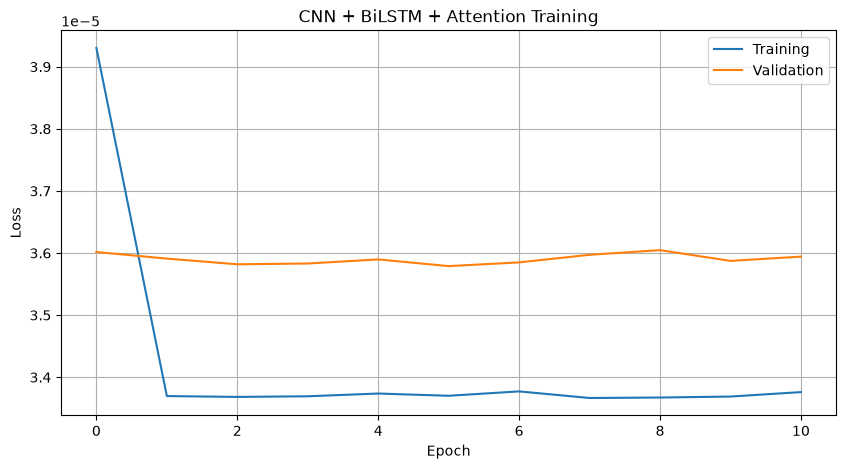

In [22]:
# ==========================================================
# Cell 20 : Training Curve
# ==========================================================

plt.figure(figsize=(10,5))

plt.plot(history["train_loss"], label="Training")
plt.plot(history["val_loss"], label="Validation")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("CNN + BiLSTM + Attention Training")

plt.grid(True)
plt.legend()

plt.savefig(
    FIGURE_DIR / "cnn_bilstm_attention_training_curve.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

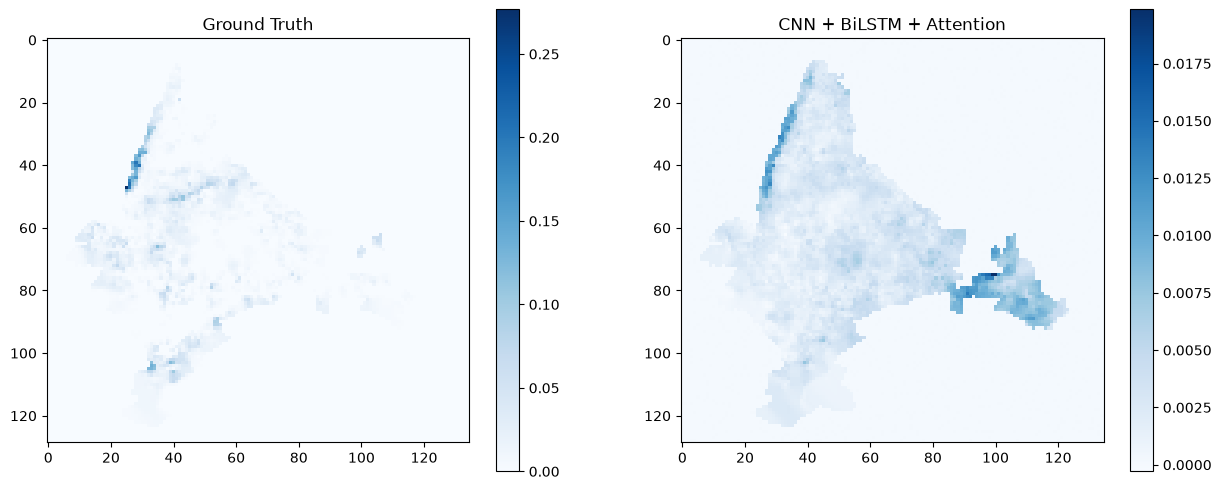

In [23]:
# ==========================================================
# Cell 21 : Prediction Visualization
# ==========================================================

sample = 100

plt.figure(figsize=(15,6))

plt.subplot(1,2,1)

plt.imshow(
    y_true[sample][0],
    cmap="Blues"
)

plt.title("Ground Truth")
plt.colorbar()

plt.subplot(1,2,2)

plt.imshow(
    y_pred[sample][0],
    cmap="Blues"
)

plt.title("CNN + BiLSTM + Attention")
plt.colorbar()

plt.savefig(
    FIGURE_DIR / "cnn_bilstm_attention_prediction.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

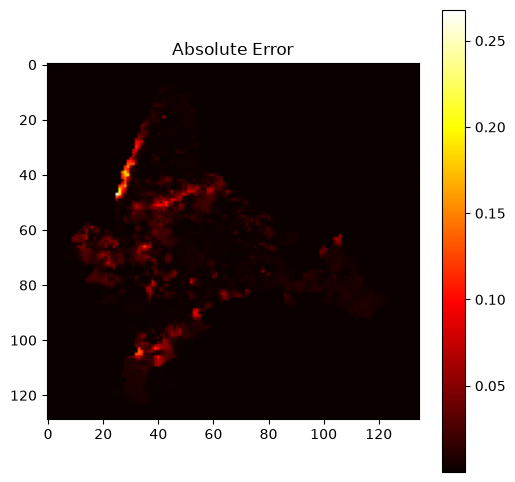

In [24]:
# ==========================================================
# Cell 22 : Error Heatmap
# ==========================================================

difference = np.abs(
    y_true[sample][0] -
    y_pred[sample][0]
)

plt.figure(figsize=(6,6))

plt.imshow(
    difference,
    cmap="hot"
)

plt.title("Absolute Error")

plt.colorbar()

plt.savefig(
    FIGURE_DIR / "cnn_bilstm_attention_error.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [25]:
# ==========================================================
# Cell 23 : Summary
# ==========================================================

print("=" * 60)
print("Notebook 4 Completed Successfully")
print("=" * 60)

print(f"MAE  : {metrics['MAE']:.6f}")
print(f"MSE  : {metrics['MSE']:.6f}")
print(f"RMSE : {metrics['RMSE']:.6f}")
print(f"R2   : {metrics['R2']:.6f}")

print("\nSaved Files")

print("✔ cnn_bilstm_attention.pth")
print("✔ metrics/cnn_bilstm_attention_metrics.csv")
print("✔ history/cnn_bilstm_attention_training_history.csv")
print("✔ figures/cnn_bilstm_attention_training_curve.png")
print("✔ figures/cnn_bilstm_attention_prediction.png")
print("✔ figures/cnn_bilstm_attention_error.png")

print("\nProject Completed Successfully!")

Notebook 4 Completed Successfully
MAE  : 0.001451
MSE  : 0.000040
RMSE : 0.006293
R2   : 0.080025

Saved Files
✔ cnn_bilstm_attention.pth
✔ cnn_bilstm_attention_metrics.csv
✔ cnn_bilstm_attention_training_history.csv
✔ cnn_bilstm_attention_training_curve.png
✔ cnn_bilstm_attention_prediction.png
✔ cnn_bilstm_attention_error.png

Project Completed Successfully!


In [26]:
# ==========================================================
# Cell 25 : Final Summary
# ==========================================================

print("="*60)
print("CNN + BiLSTM + Attention Training Completed")
print("="*60)

print("\nEvaluation Metrics")

print(f"MAE  : {metrics['MAE']:.6f}")
print(f"MSE  : {metrics['MSE']:.6f}")
print(f"RMSE : {metrics['RMSE']:.6f}")
print(f"R2   : {metrics['R2']:.6f}")

print("\nSaved Files")

print("✔ cnn_bilstm_attention.pth")
print("✔ history/cnn_bilstm_attention_training_history.csv")
print("✔ metrics/cnn_bilstm_attention_metrics.csv")
print("✔ figures/cnn_bilstm_attention_training_curve.png")
print("✔ figures/cnn_bilstm_attention_prediction.png")
print("✔ figures/cnn_bilstm_attention_error.png")

print("\nProject Completed Successfully!")
print("="*60)

CNN + BiLSTM + Attention Training Completed

Evaluation Metrics
MAE  : 0.001451
MSE  : 0.000040
RMSE : 0.006293
R2   : 0.080025

Saved Files
✔ cnn_bilstm_attention_final.pth
✔ cnn_bilstm_attention_training_history.csv
✔ cnn_bilstm_attention_metrics.csv
✔ cnn_bilstm_attention_training_curve.png
✔ cnn_bilstm_attention_prediction.png
✔ cnn_bilstm_attention_error.png

Project Completed Successfully!
